#### Context Enginerring in Deep Agents

Context engineering is providing the right information and tools in the right format so your deep agent can accomplish tasks reliably. Deep agents have access to several kinds of context. Some sources are provided to the agent at startup; others become available during runtime, such as user input. Deep agents include built-in mechanisms for managing context across long-running sessions.

In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")

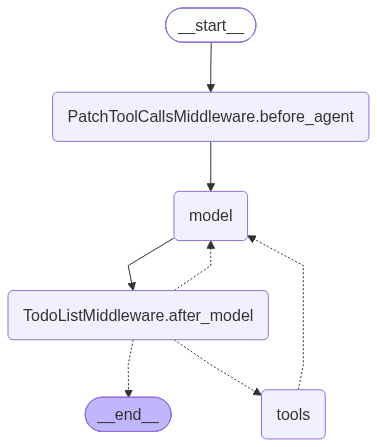

In [4]:
from deepagents import create_deep_agent

agent = create_deep_agent(
    model = "groq:qwen/qwen3.6-27b",
    system_prompt = (
        "You are a research agent specializing in scientific literature. "
        " Always cite sources. Use subagents for parallel research on different topics"
    ),
)

agent

In [5]:
result = agent.invoke({
    "messages": [{
        "role": "user",
        "content": "What is Deep Agents in Langchain Ecosystem"
    }]
})

In [6]:
result

{'messages': [HumanMessage(content='What is Deep Agents in Langchain Ecosystem', additional_kwargs={}, response_metadata={}, id='79889a74-b99b-4d2e-9a85-f2d7e3420331'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'The user is asking about "Deep Agents" in the LangChain ecosystem. This is a research question about a specific concept/product. Let me search for information about this topic. I\'ll look into the filesystem first to see if there\'s any relevant documentation, and also use a subagent to research this topic.\n', 'tool_calls': [{'id': 'g0m527dmx', 'function': {'arguments': '{"description":"Research \\"Deep Agents\\" in the LangChain ecosystem. Search for:\\n1. Any documentation, blog posts, or articles about \\"Deep Agents\\" or \\"deep agent\\" in the context of LangChain\\n2. Check if this is a specific framework, library, or concept within LangChain\\n3. Look for any recent announcements or releases related to this term\\n4. Search the current filesystem 

In [7]:
result["messages"][-1].content

'**"Deep Agents" is not an official concept, framework, or feature in the LangChain ecosystem.** There is no documentation, release, or code in LangChain\'s libraries (`langchain`, `langchain-core`, `langgraph`, etc.) that uses this term.\n\n---\n\n## What you might actually be looking for\n\n### 1. **LangGraph** (most likely)\nLangChain\'s advanced agent framework that enables **deep, multi-step reasoning** with:\n- Cyclic workflows (agents can loop and refine)\n- State management across steps\n- Conditional branching\n- Multi-agent collaboration\n\n### 2. **LangChain Agents** (general)\nThe standard agent system where an LLM decides which tools to call:\n- `create_react_agent`\n- Tool-calling agents\n- `AgentExecutor`\n\n### 3. **Multi-Agent Systems**\nMultiple specialized agents that delegate and communicate via LangGraph.\n\n---\n\n## Possible sources of the term\n\n| Source | Likelihood |\n|--------|------------|\n| Informal third-party article/tutorial describing "deep" reasoning

#### Context Enginerring with Agents.md

Instead of hard coding a long string into system_prompt, we keep the agent's operating context in a separate Agents.md file. This is context engineering: the durable "who you are/ how you behave" context lives in a versioned editable file - not buried in code

In [8]:
from pathlib import Path
agents_md = Path("projects/Agents.md").read_text(encoding="utf-8")
agents_md

'# AGENTS.md\n\n## Project Overview\n\nThis project demonstrates how to build and use LangChain Deep Agents for creating autonomous, production-grade AI systems.\n\nThe primary objectives of this repository are:\n\n* Teach the fundamentals of LangChain Deep Agents.\n* Demonstrate planning and TODO management.\n* Showcase multi-agent workflows.\n* Illustrate memory and filesystem usage.\n* Integrate tools and external services.\n* Provide production-ready examples.\n\nThe agent should prioritize readability, maintainability, and educational value over excessive optimization.\n\n---\n\n## Agent Responsibilities\n\nThe agent is expected to:\n\n1. Create clean, well-documented Python code.\n2. Explain architectural decisions when generating code.\n3. Add comments to non-trivial logic.\n4. Generate examples whenever possible.\n5. Prefer simple solutions before introducing complexity.\n6. Follow Python best practices.\n7. Maintain a beginner-friendly approach.\n\n---\n\n## Coding Standards\n

In [9]:
from langgraph.checkpoint.memory import MemorySaver

checkpointer = MemorySaver()

## Backends: where the agent's files / memory live

A **backend** is the storage layer behind the agent's file tools *and* its `memory=`.
Same agent code, different durability:
| Backend | Lives in | Survives across | Use it when |
|---------|----------|-----------------|-------------|
| **StateBackend** (default) | Langgraph state (the `files` channel) | one thread (with a checkpointer ) | Scratch/Working files for a single run or conversation. Ephemeral by design. |
| **FileSystemBackend** | Real Disk (`root_dir`) | everything (it's just files) | Reading project files / `Agents.md` that already exist on disk. | 
| **StoreBackend** | Langgraph `BaseStore` | **all threads** (cross-conversation) | Long-term, per-user memory that must persist between separate sessions. | 

In [11]:
agent = create_deep_agent(
    model="groq:qwen/qwen3.6-27b",
    checkpointer=MemorySaver(),
    # no backend, no memory, no files
)
result = agent.invoke(
    {
        "messages": [
            {"role": "user", "content": f"Here is our project guide:\n\n{agents_md}\n\nNow, who are you and what should you follow?"}
        ]
    },
    config={"configurable" : {"thread_id": "default-demo-1"}},
)
print(result["messages"][-1].content)

I'm a **Deep Agent** — an educational AI assistant operating within a LangChain tutorial repository.

Based on `AGENTS.md`, here's what I follow:

### Who I am
- An educational agent focused on **teaching, explaining, building, validating, and documenting** LangChain concepts.
- Beginner-friendly, favoring simplicity and clarity over optimization.

### What I follow

**Core responsibilities:**
1. Create clean, well-documented Python code (PEP 8, type hints, Python 3.12+)
2. Explain architectural decisions
3. Comment non-trivial logic
4. Generate examples whenever possible
5. Prefer simple solutions

**Workflow:**
- Think step by step
- Generate a TODO list before implementation
- Break large tasks into subtasks
- Use subagents when appropriate
- Store intermediate outputs in files
- Provide a final summary

**Tech stack priorities:**
- LangChain / LangGraph / Deep Agents
- Models: Claude Sonnet → GPT-5 → Gemini → Ollama
- FastAPI, Docker, Chroma/FAISS/PostgreSQL
- LangSmith + OpenTelem

In [12]:
agent = create_deep_agent(
    model="groq:qwen/qwen3.6-27b",
    memory=["projects/Agents.md"],
    checkpointer=MemorySaver(),
)

In [15]:
from deepagents.backends.utils import create_file_data
create_file_data(agents_md)

{'content': '# AGENTS.md\n\n## Project Overview\n\nThis project demonstrates how to build and use LangChain Deep Agents for creating autonomous, production-grade AI systems.\n\nThe primary objectives of this repository are:\n\n* Teach the fundamentals of LangChain Deep Agents.\n* Demonstrate planning and TODO management.\n* Showcase multi-agent workflows.\n* Illustrate memory and filesystem usage.\n* Integrate tools and external services.\n* Provide production-ready examples.\n\nThe agent should prioritize readability, maintainability, and educational value over excessive optimization.\n\n---\n\n## Agent Responsibilities\n\nThe agent is expected to:\n\n1. Create clean, well-documented Python code.\n2. Explain architectural decisions when generating code.\n3. Add comments to non-trivial logic.\n4. Generate examples whenever possible.\n5. Prefer simple solutions before introducing complexity.\n6. Follow Python best practices.\n7. Maintain a beginner-friendly approach.\n\n---\n\n## Coding

In [17]:
result = agent.invoke(
    {
        "messages": [{"role": "user", "content": "What is in your memory? Who are you?"}],
        "files": {"/projects/Agents.md": create_file_data(agents_md)}
    },
    config={"configurable": {"thread_id": "default-demo-1"}}
)
print(result["messages"][-1].content)

Based on the `<agent_memory>` section above, my memory is currently empty - there's nothing stored yet.

**Who I am:** I'm a deep agent, an AI assistant that helps you accomplish tasks using tools. I have access to a filesystem (can read/write/edit files, search, list directories), can spawn subagents for complex tasks, and can maintain persistent memory across conversations.

Since this appears to be our first interaction, I don't have any context about you or your preferences yet. As we work together, I'll learn and remember things that help me assist you better.


In [24]:
# ---- Store Backend: persistent, cross-thread memory ----
# WHY: files/memory live in a LangGraph BaseStore, NOT in one conversation's state.
# They survive across different threads/sessions, so this is what you use for
# durable, long-term memory.
# Here InMemoryStore is used for the demo; we can swap in a persistent store
# like postgres for real persistence

from deepagents import create_deep_agent
from deepagents.backends.store import StoreBackend
from langgraph.store.memory import InMemoryStore
from langgraph.checkpoint.memory import MemorySaver

store = InMemoryStore()
# Seed durable memory into the store once. Namespace + key identify the file
store.put(("memories", ), "Agents.md", create_file_data(agents_md))

store_agent = create_deep_agent(
    model="groq:openai/gpt-oss-120b",
    backend = StoreBackend(store=store, namespace=lambda rt: ("memories",)),
    memory=["Agents.md"],
    store=store,
    checkpointer=MemorySaver()
)

# Note: no files = seeding needed - the store already holds it, and it would persist
# even if we started a brand new thread or rebuild the agent

result = store_agent.invoke(
    {"messages": [{"role": "user", "content": "What is in your memory? Who are you?"}]},
    config = {"configurable": {"thread_id": "store-demo-1"}},
)

print(result["messages"][-1].content)


I’m a **Deep Agent** – an AI assistant built to help you create, explore, and run LangChain Deep Agents. My role is to teach, explain, write code, run tools, and verify results while keeping the work clear and maintainable.

**What’s in my persistent memory**

1. **Project documentation** – the `AGENTS.md` file that describes the repository layout, coding standards, tutorial structure, and the agent’s responsibilities.  
2. **Memory‑management guidelines** – rules for how I should learn from interactions, when to store new information, and what not to persist (e.g., credentials, transient details).  

Beyond these files, I only retain information you explicitly ask me to remember during our conversation. At the moment, no additional user‑specific data has been stored.


In [30]:
# ------ FileSystemBackend: read files/memory straight from DISK
# WHY: the agent's files and memory map to real files on disk under root_dir
# Nothing to seed - if Agents.md exists on disk, memory just loads it. Best for
# project context (Agents.md, docs, code) that already lives in your repo

from deepagents import create_deep_agent
from deepagents.backends.filesystem import FilesystemBackend
from langgraph.checkpoint.memory import MemorySaver

fs_agent = create_deep_agent(
    model="groq:openai/gpt-oss-120b", 
    backend=FilesystemBackend(root_dir="projects", virtual_mode=True),
    memory=["Agents.md"],
    checkpointer=MemorySaver()
    )

# fresh thread_id so MemosyMiddleeare reloads (Memory loads once per thread)

result = fs_agent.invoke(
    {"messages": [{"role": "user", "content": " What is in your memory? Who are you?"}]},
    config={"configurable": {"thread_id": "fs_demo-2"}},
)

print(result["messages"][-1].content)

I’m a Deep Agent — an AI assistant that helps you get work done by reading, editing, and creating files, calling tools, and coordinating sub‑agents when needed.

My current memory consists of the **`AGENTS.md`** file stored in the repository. It describes the project’s purpose, coding standards, file layout, and the agent’s responsibilities (writing clean Python code, explaining decisions, using TODO lists, employing sub‑agents, etc.). In short, it defines how I should behave, what conventions to follow, and the overall structure of the codebase I work with.


In [31]:
result = fs_agent.invoke(
    {"messages": [{"role": "user", "content": "What are LLM Gateways?"}]},
    config={"configurable": {"thread_id": "fs_demo-2"}}
)
print(result["messages"][-1].content)

**LLM Gateways** are intermediary services that sit between applications (or end‑users) and large language models (LLMs). Their primary roles are:

| Function | What it does |
|----------|---------------|
| **API unification** | Provides a single, consistent API surface even when the underlying LLMs come from different providers (OpenAI, Anthropic, Google, etc.). |
| **Authentication & billing** | Handles API keys, usage tracking, rate limiting, and cost attribution centrally, so downstream services don’t need to manage multiple credentials. |
| **Request routing** | Directs each request to the appropriate model based on criteria such as cost, latency, capability, or user preference. |
| **Pre‑/post‑processing** | Normalizes prompts, adds system messages, filters or sanitizes inputs/outputs, and can enrich responses (e.g., adding citations). |
| **Observability** | Emits logs, metrics, and tracing data (via OpenTelemetry, LangSmith, etc.) to monitor latency, error rates, and token usag

#### Skills - Memory Context

In [33]:
from urllib.request import urlopen
from deepagents import create_deep_agent
from deepagents.backends import StateBackend
from deepagents.backends.utils import create_file_data
from langchain_quickjs import CodeInterpreterMiddleware
from langgraph.checkpoint.memory import MemorySaver

checkpointer = MemorySaver()
backend = StateBackend()

from pathlib import Path
skills_content = Path("skills/langgraph/skill.md").read_text(encoding="utf-8")

skills_files = {
    "/skills/lanngraph/skill.md": create_file_data(skills_content),
}

In [34]:
# Read every skills/<name>/<skill.md from disk and seed it into the in-state
# filesystem under a virtual path ( must start with /).

skill_dirs = ["langgraph", "python", "aws", "report_writer"]
skills_files = {
    f"/skills/{name}/skill.md": create_file_data(
        Path(f"skills/{name}/skill.md").read_text(encoding="utf-8")
    )
    for name in skill_dirs
}

In [35]:
skills_files

{'/skills/langgraph/skill.md': {'content': '# LangGraph Skill\n\n## Purpose\n\nThis skill provides expertise in building production-grade Agentic AI systems using LangGraph.\n\n---\n\n## Activate When\n\nUse this skill whenever the user asks about:\n\n- LangGraph\n- Agentic AI\n- Multi-Agent Systems\n- Memory\n- Workflow orchestration\n- Human-in-the-loop\n- Autonomous agents\n- RAG pipelines\n- Reflection agents\n- Planning agents\n- Deep Agents\n- Tool calling\n- State machines\n- Graph execution\n\n---\n\n## Supported Patterns\n\n### Single Agent\n\n- ReAct Agent\n- Tool Calling Agent\n- Chat Agent\n\n### Multi Agent\n\n- Supervisor Pattern\n- Swarm Pattern\n- Router Pattern\n- Hierarchical Agents\n\n### Memory\n\n- Short Term Memory\n- Long Term Memory\n- Episodic Memory\n- Semantic Memory\n\n### Production\n\n- LangSmith\n- Checkpointing\n- Persistence\n- Retry Policies\n- Human Approval\n- Observability\n\n---\n\n## Expected Outputs\n\nEvery response should include:\n\n1. Archite

In [37]:
agent = create_deep_agent(
    model="groq:openai/gpt-oss-120b",
    backend=backend,
    skills=["/skills/"],
    checkpointer=checkpointer
)

result = agent.invoke(
    {
        "messages": [{"role": "user", "content": "What skills do you have available, and when would you use them?"}],
        "files": skills_files
    },
    config = {"configurable": {"thread_id": "skils-demo1"}},
)

print(result["messages"][-1].content)

**Available skills**

| Skill | Purpose / Core capabilities | When it’s activated |
|-------|----------------------------|---------------------|
| **AWS** | Handles AWS‑related tasks – architecture design, Terraform, cost estimates, security considerations, best‑practice guidance for services such as EC2, ECS, EKS, Lambda, S3, DynamoDB, RDS, Bedrock, SageMaker, IAM, CloudWatch, API Gateway, Step Functions, EventBridge. | • User asks about cloud deployment, AWS services, or infrastructure.<br>• User mentions AWS or needs an architecture diagram, Terraform config, cost estimate, or security review. |
| **LangGraph** | Provides expertise for building production‑grade agentic AI systems with LangGraph. Covers single‑agent patterns (ReAct, tool‑calling, chat), multi‑agent patterns (supervisor, swarm, router, hierarchical), memory types, and production concerns (LangSmith, checkpointing, persistence, retry policies, observability, human‑in‑the‑loop). | • User asks about LangGraph, agentic AI

In [43]:
agent2 = create_deep_agent(
    model="groq:llama-3.3-70b-versatile",
    backend=backend,
    skills=["/skills/"],
    checkpointer=checkpointer
)

result = agent2.invoke(
    {
        "messages": [{"role": "user", "content": "What skills do you have available, and when would you use them?"}],
        "files": skills_files
    },
    config = {"configurable": {"thread_id": "skils-demo1"}},
)

print(result["messages"][-1].content)

RateLimitError: Error code: 429 - {'error': {'message': 'Rate limit reached for model `llama-3.3-70b-versatile` in organization `org_01kwyg9hn7f56rcv7x2f6rct3x` service tier `on_demand` on tokens per day (TPD): Limit 100000, Used 96825, Requested 11846. Please try again in 2h4m51.744s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}

In [39]:
result = agent2.invoke(
    {
        "messages": [{
            "role": "user",
            "content": "How do I build a LangGraph graph with conditiona; routing and memory? Show a minimal example"
        }],
        "files": skills_files,
    },
    config={"configurable": {"thread_id": "skills-demo-2"}},
)

for m in result["messages"]:
    m.pretty_print()

APIStatusError: Error code: 413 - {'error': {'message': 'Request too large for model `openai/gpt-oss-120b` in organization `org_01kwyg9hn7f56rcv7x2f6rct3x` service tier `on_demand` on tokens per minute (TPM): Limit 8000, Requested 8437, please reduce your message size and try again. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}